# 🌍 GeoPandas & Spatial Rescaling to NUTS3

**Goal:** Learn how to work with geographic data in Python, visualise it, and bring data at different spatial resolutions to the NUTS3 level.

---

**What you need to install:**
```
pip install geopandas shapely mapclassify 
```

**NUTS3 Shapefile:** Download from Eurostat:  
Get the file here: https://ec.europa.eu/eurostat/web/gisco/geodata/statistical-units/territorial-units-statistics

Select:
- NUTS year: 2024
- Format: SHP
- Geometry: Polygons (RG)
- Scale: 01M
- CRS: EPSG:4326

Unzip the file and keep all extracted files in the same folder.


---
## Part 0 — Imports and Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')          # keep the output clean

import numpy as np
import pandas as pd
import geopandas as gpd                    # the main library we study today

from shapely.geometry import Point, Polygon, box

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Fix a random seed so results are the same every time we run the notebook
np.random.seed(42)

print(f"GeoPandas : {gpd.__version__}")
print(f"Pandas    : {pd.__version__}")
print("Setup OK ✓")

GeoPandas : 1.1.3
Pandas    : 3.0.1
Setup OK ✓


---
## Part 1 — What is GeoPandas?

**GeoPandas** extends the pandas library to support spatial (geographic) data.

The core idea is simple:
- A normal pandas `DataFrame` has columns of numbers, strings, dates…
- A GeoPandas `GeoDataFrame` has **all of that, plus a special column called `geometry`**
- The `geometry` column stores shapes: points, lines, or polygons

GeoPandas relies on three key libraries under the hood:
| Library | Role |
|---------|------|
| **Shapely** | Defines and manipulates geometric objects (Point, Polygon…) |
| **PyProj** | Handles coordinate reference systems (CRS) and projections |
| **Fiona / PyGDAL** | Reads and writes spatial file formats (Shapefile, GeoJSON…) |

You do not need to import these directly — GeoPandas wraps them for you.

### 1.1 — Build a GeoDataFrame from scratch

Let's create a tiny GeoDataFrame with three European capital cities.
This shows the basic structure before we open any real file.

In [3]:
# --- Step 1: Create a regular pandas DataFrame with city info ---
cities_df = pd.DataFrame({
    'city'      : ['Rome',  'Berlin', 'Paris'],
    'country'   : ['IT',    'DE',     'FR'],
    'population': [2_873_000, 3_645_000, 2_161_000],  # rough figures
    'lon'       : [12.4964,  13.4050,   2.3522],      # longitude in degrees
    'lat'       : [41.9028,  52.5200,   48.8566],     # latitude in degrees
})

# --- Step 2: Turn lon/lat columns into Shapely Point objects ---
# gpd.points_from_xy() is a helper that does this for us
cities_gdf = gpd.GeoDataFrame(
    cities_df,
    geometry=gpd.points_from_xy(cities_df['lon'], cities_df['lat']),
    crs='EPSG:4326'   # WGS84 — the standard lon/lat coordinate system
)

print(type(cities_gdf))  # confirm it is a GeoDataFrame, not a plain DataFrame
cities_gdf

<class 'geopandas.geodataframe.GeoDataFrame'>


,city,country,population,lon,lat,geometry
0,Rome,IT,2873000,12.4964,41.9028,POINT (12.4964 41.9028)
1,Berlin,DE,3645000,13.4050,52.5200,POINT (13.405 52.52)
2,Paris,FR,2161000,2.3522,48.8566,POINT (2.3522 48.8566)


In [5]:
# --- Inspect the geometry column ---

# The CRS tells us what coordinate system we are in
print("CRS:", cities_gdf.crs)

# .geometry gives direct access to the geometry column
print("\nGeometry type of each row:")
print(cities_gdf.geometry.geom_type)

# For points, .x and .y extract the coordinates
print("\nLongitude (x):", cities_gdf.geometry.x.values)
print("Latitude  (y):", cities_gdf.geometry.y.values)

CRS: EPSG:4326

Geometry type of each row:
0    Point
1    Point
2    Point
dtype: str

Longitude (x): [12.4964 13.405   2.3522]
Latitude  (y): [41.9028 52.52   48.8566]


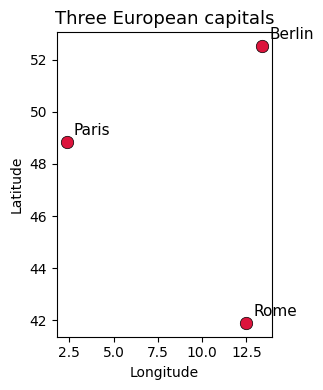

In [ ]:
# --- Plot the three cities ---
fig, ax = plt.subplots(figsize=(10,4)) # the real figsize will be changed by geopandas to have right geographic proportions
cities_gdf.plot(    
    color='crimson',
    markersize=80,
    edgecolor='black',
    linewidth=0.5,
    ax=ax

)


# Add city name labels
for _, row in cities_gdf.iterrows():
    ax.annotate(
        row['city'],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5), textcoords='offset points',
        fontsize=11
    )

ax.set_title('Three European capitals', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

### 1.2 — Coordinate Reference Systems (CRS)

A **CRS** defines how coordinates map to locations on Earth.

- **EPSG:4326** (WGS84) — the GPS system. Units are **degrees** (longitude, latitude).
- **EPSG:3035** (ETRS89 / LAEA) — the official projection for European statistics. Units are **metres**. This is what Eurostat uses.

**Why does it matter?**  
If you mix layers with different CRS, the shapes will not line up.  
Also, area and distance calculations in degrees are inaccurate — always reproject to metres first.

> **Rule of thumb:** always check `.crs` when you load a file, and always reproject to the same CRS before any spatial operation.

In [20]:
# --- Reproject from WGS84 (degrees) to ETRS89-LAEA (metres) ---

cities_m = cities_gdf.to_crs('EPSG:3035')   # .to_crs() does the reprojection

print("Original CRS (degrees):", cities_gdf.crs)
print("Reprojected CRS (metres):", cities_m.crs)

# The coordinates now look very different — they are in metres from a reference point
print("\nCoordinates in EPSG:3035:")
print(cities_m[['city', 'geometry']])

Original CRS (degrees): EPSG:4326
Reprojected CRS (metres): EPSG:3035

Coordinates in EPSG:3035:
     city                         geometry
0    Rome  POINT (4528866.756 2092277.143)
1  Berlin   POINT (4552036.45 3273268.274)
2   Paris  POINT (3760771.865 2889484.802)


### 1.3 — Working with Polygons

Real geographic data is mostly polygons (country borders, regions, land parcels).  
Let's build a few toy polygons to practice before loading real data.

In [21]:
# --- Create three simple square polygons ---
# shapely.geometry.box(minx, miny, maxx, maxy) creates a rectangle

polygons_gdf = gpd.GeoDataFrame({
    'name' : ['Region A', 'Region B', 'Region C'],
    'value': [10, 40, 70],
    'geometry': [
        box(0, 0, 2, 2),   # square from (0,0) to (2,2)
        box(2, 0, 5, 2),
        box(0, 2, 5, 5),
    ]
}, crs='EPSG:3035')  # pretend these are in metres

# Useful geometric properties
polygons_gdf['area_m2']    = polygons_gdf.geometry.area       # area in CRS units²
polygons_gdf['perimeter_m'] = polygons_gdf.geometry.length    # perimeter
polygons_gdf['centroid']   = polygons_gdf.geometry.centroid   # centre point

polygons_gdf[['name', 'value', 'area_m2', 'perimeter_m']]

,name,value,area_m2,perimeter_m
0,Region A,10,4.0,8.0
1,Region B,40,6.0,10.0
2,Region C,70,15.0,16.0


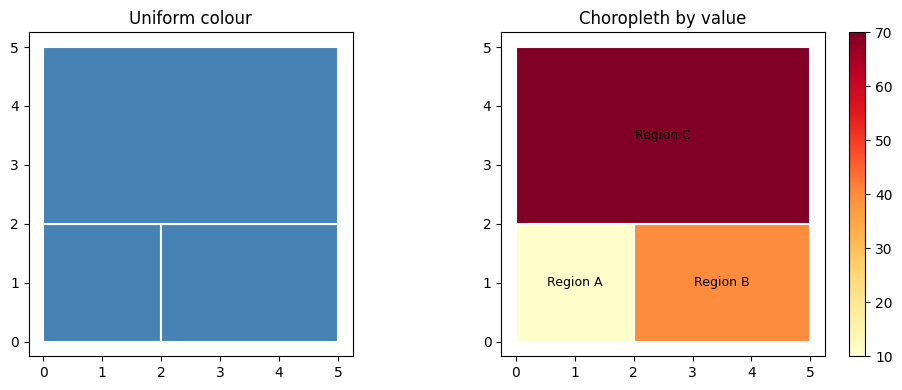

In [22]:
# --- Choropleth: colour polygons by their 'value' column ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: uniform colour
polygons_gdf.plot(ax=axes[0], color='steelblue', edgecolor='white', linewidth=1.5)
axes[0].set_title('Uniform colour')

# Right: colour mapped to the 'value' column — this is a choropleth map
polygons_gdf.plot(
    ax=axes[1],
    column='value',       # which column drives the colour
    cmap='YlOrRd',        # colour palette (Yellow → Orange → Red)
    legend=True,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Choropleth by value')

# Add region labels on the right map
for _, row in polygons_gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    axes[1].text(cx, cy, row['name'], ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

---
## Part 2 — Loading and Visualising the NUTS3 Shapefile

**NUTS** stands for *Nomenclature of Territorial Units for Statistics*.  
It is the official EU system for dividing countries into comparable regions:

| Level | Typical unit | N. of regions (~2024) |
|-------|-------------|----------------------|
| NUTS0 | Country | 39 |
| NUTS1 | Major region (e.g. Nord-Ovest in Italy) | ~115 |
| NUTS2 | Province-group (e.g. Piemonte) | ~299 |
| NUTS3 | Province / district (e.g. Torino) | ~1,345 |

The NUTS code encodes the hierarchy: `ITH` (NUTS1) → `ITH1` (NUTS2) → `ITH11` (NUTS3).  
This is crucial for matching data across levels — we will use it later.


In [28]:
# --- Load the NUTS shapefile ---
# gpd.read_file() can read Shapefiles, GeoJSON, GeoPackage, and many other formats

NUTS_PATH = 'data/nuts/NUTS_RG_01M_2024_4326.shp'

nuts_all = gpd.read_file(NUTS_PATH)

print(f"Rows (all NUTS levels): {len(nuts_all)}")
print(f"Columns              : {list(nuts_all.columns)}")
print(f"CRS                  : {nuts_all.crs}")

Rows (all NUTS levels): 1798
Columns              : ['NUTS_ID', 'LEVL_CODE', 'CNTR_CODE', 'NAME_LATN', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'geometry']
CRS                  : EPSG:4326


In [29]:
# --- Preview the first few rows ---
nuts_all.head()

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,AL011,3,AL,Dibër,Dibër,NaN,NaN,NaN,"POLYGON ((20.3461 41.8761, 20.34106 41.85659, ..."
1,AL012,3,AL,Durrës,Durrës,NaN,NaN,NaN,"POLYGON ((19.8072 41.5662, 19.81828 41.56444, ..."
2,AL013,3,AL,Kukës,Kukës,NaN,NaN,NaN,"POLYGON ((20.11943 42.52485, 20.16464 42.50607..."
3,AL031,3,AL,Berat,Berat,NaN,NaN,NaN,"POLYGON ((19.96849 40.86741, 19.96939 40.86439..."
4,AL032,3,AL,Fier,Fier,NaN,NaN,NaN,"POLYGON ((19.62572 41.06464, 19.62615 41.06414..."


In [30]:
# --- The file contains ALL levels mixed together.
#     The column 'LEVL_CODE' tells us the level (0, 1, 2, or 3).

print("How many polygons per NUTS level?")
print(nuts_all['LEVL_CODE'].value_counts().sort_index())

# --- Keep only NUTS3 ---
nuts3 = nuts_all[nuts_all['LEVL_CODE'] == 3].copy()
nuts3 = nuts3.reset_index(drop=True)

print(f"\nNUTS3 regions: {len(nuts3)}")

How many polygons per NUTS level?
LEVL_CODE
0      39
1     115
2     299
3    1345
Name: count, dtype: int64

NUTS3 regions: 1345


In [31]:
# --- Also build NUTS2 (we will need it in Part 4) ---
nuts2 = nuts_all[nuts_all['LEVL_CODE'] == 2].copy().reset_index(drop=True)

# --- Understanding the NUTS code structure ---
# Example: 'ITH11' = Italy (IT) + NUTS1 H + NUTS2 H1 + NUTS3 H11
# We can derive the parent NUTS2 code by taking the first 4 characters
nuts3['NUTS2_ID'] = nuts3['NUTS_ID'].str[:4]

# Show a sample for Italy
nuts3[nuts3['CNTR_CODE'] == 'IT'][['NUTS_ID', 'NUTS2_ID', 'NAME_LATN']].head(8)

,NUTS_ID,NUTS2_ID,NAME_LATN
839,ITH54,ITH5,Modena
840,ITH55,ITH5,Bologna
843,ITI22,ITI2,Terni
844,ITG2D,ITG2,Sassari
845,ITG2E,ITG2,Nuoro
846,ITI44,ITI4,Latina
847,ITI45,ITI4,Frosinone
849,ITI31,ITI3,Pesaro e Urbino


### 2.1 — Basic Map of NUTS3 Europe

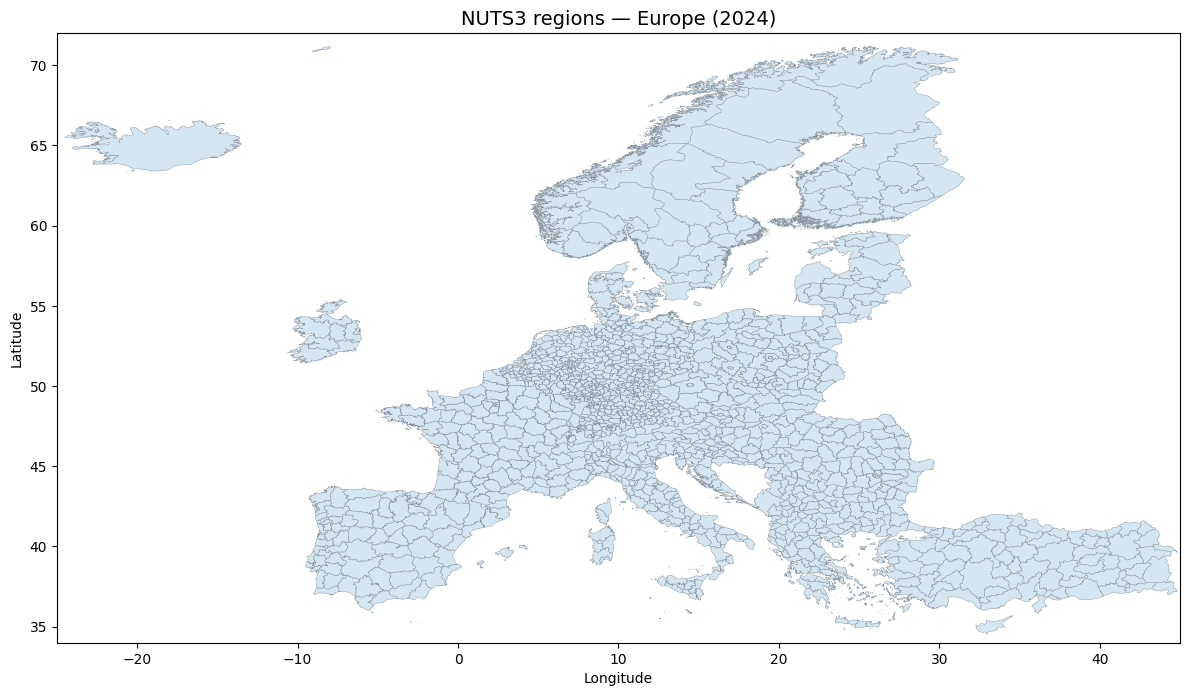

In [37]:
# --- Plot all NUTS3 regions ---
# We clip to the continental Europe bounding box to exclude overseas territories

# Bounding box: lon -25 to 45, lat 34 to 72
bbox = box(-25, 34, 45, 72)
nuts3_eu = nuts3[nuts3.geometry.intersects(bbox)].copy()

fig, ax = plt.subplots(figsize=(12, 9))

nuts3_eu.plot(
    ax=ax,
    color='#d4e6f1',       # light blue fill
    edgecolor='#85929e',   # grey borders
    linewidth=0.3
)


ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)
ax.set_title('NUTS3 regions — Europe (2024)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

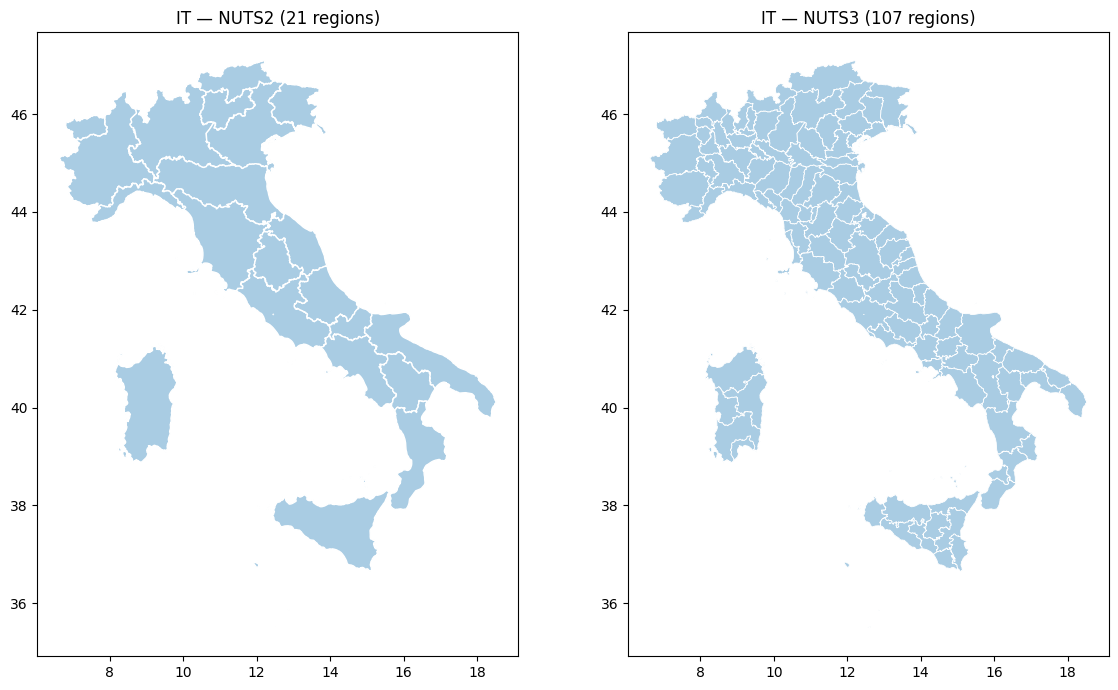


Each NUTS2 region is made of ~5.1 NUTS3 regions on average


In [ ]:
# --- Filter to a single country and compare NUTS2 vs NUTS3 boundaries ---

country = 'IT'   # try 'DE', 'FR', 'ES', 'PL' …

nuts3_country = nuts3[nuts3['CNTR_CODE'] == country]
nuts2_country = nuts2[nuts2['CNTR_CODE'] == country]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# Left: NUTS2 boundaries
nuts2_country.plot(ax=axes[0], color='#a9cce3', edgecolor='white', linewidth=1)
axes[0].set_title(f'{country} — NUTS2 ({len(nuts2_country)} regions)', fontsize=12)
# axes[0].set_aspect('equal')

# Right: NUTS3 boundaries
nuts3_country.plot(ax=axes[1], color='#a9cce3', edgecolor='white', linewidth=0.6)
axes[1].set_title(f'{country} — NUTS3 ({len(nuts3_country)} regions)', fontsize=12)
# axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nEach NUTS2 region is made of ~{len(nuts3_country)/len(nuts2_country):.1f} NUTS3 regions on average")

### 2.2 — Choropleth map on NUTS3

A choropleth is a map where regions are coloured by the value of a variable.  
Here we use the **area** of each NUTS3 polygon as an example variable —  
your real variable will come from your data source.

In [40]:
# --- Reproject to EPSG:3035 (metres) before computing area ---
# Area in degrees is meaningless. Always reproject first!

nuts3_m = nuts3_eu.to_crs('EPSG:3035').copy()
nuts3_m['area_km2'] = nuts3_m.geometry.area / 1e6   # m² → km²

print("Area statistics (km²):")
print(nuts3_m['area_km2'].describe().round(1))

Area statistics (km²):
count      1330.0
mean       4157.0
std        7126.0
min          13.5
25%         864.0
50%        2227.0
75%        5505.8
max      105908.7
Name: area_km2, dtype: float64


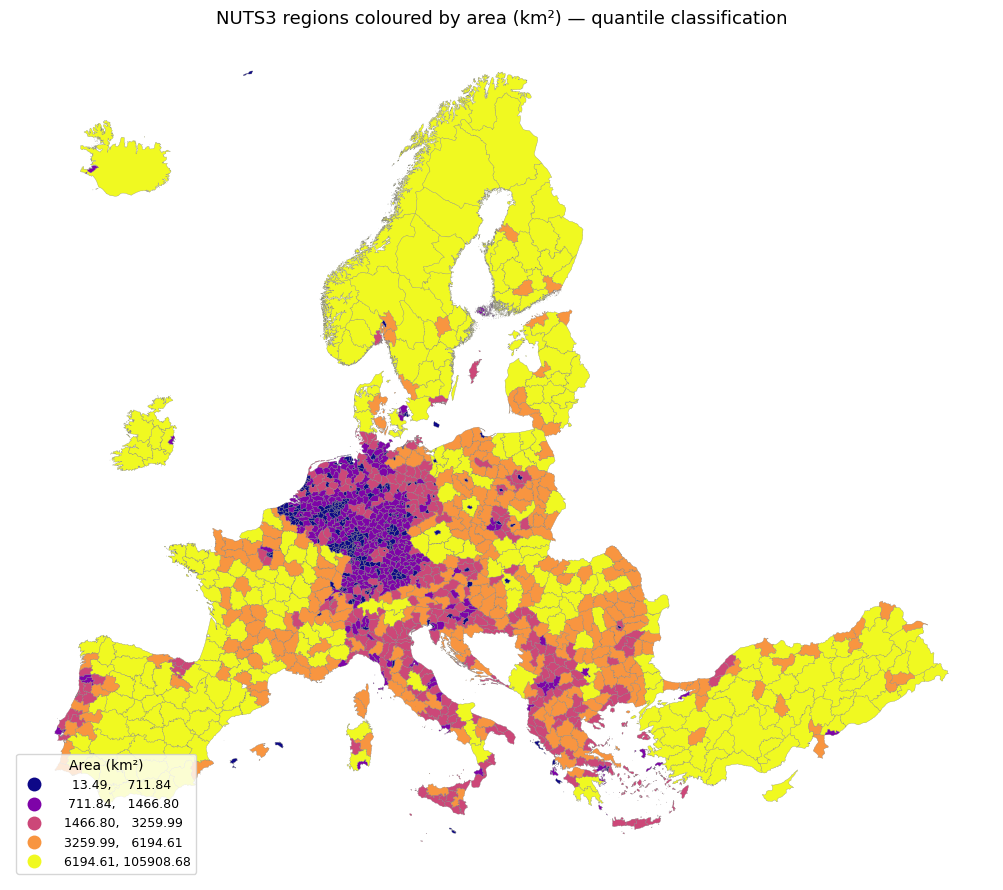

In [45]:
# --- Choropleth: NUTS3 coloured by area ---

fig, ax = plt.subplots(figsize=(12, 9))

nuts3_m.plot(
    ax=ax,
    column='area_km2',
    cmap='plasma',          # try also 'viridis', 'RdYlGn', 'Blues'
    scheme='quantiles',     # classify values into equal-frequency bins
    k=5,                    # number of bins
    legend=True,
    legend_kwds={
        'title'     : 'Area (km²)',
        'loc'       : 'lower left',
        'fontsize'  : 9
    },
    edgecolor='grey',
    linewidth=0.2
)

ax.set_title('NUTS3 regions coloured by area (km²) — quantile classification', fontsize=13)
ax.set_axis_off()   # hide axes for a cleaner map look
plt.tight_layout()
plt.show()


# NOTE: 'scheme' requires the mapclassify package: pip install mapclassify
# If not installed, remove scheme= and k= and GeoPandas will use a linear scale.

---
## Part 3 - The Spatial Mismatch Problem

In practice, the data you want to analyse is **never at the same resolution as your target geography**.  
Your target is NUTS3. Your data might come from:

| Situation | Example |
|-----------|--------|
| **Coarser** than NUTS3 | A Eurostat indicator available only at NUTS2 |
| **Finer** than NUTS3 | A satellite-derived raster at 1 km × 1 km |
| **Different polygons** | Administrative units that cut across NUTS3 borders |

Each case needs a different strategy. The rest of this notebook covers all three.

---

**Key distinction — intensive vs extensive variables:**

- **Extensive** (additive): the total increases if you add more area.  
  Examples: total energy production (MWh), total population, total investment (€).  
  → When aggregating sub-units: **sum**. When splitting: **split proportionally to area**.

- **Intensive** (rate/density): the value does not depend on the size of the area.  
  Examples: temperature (°C), energy price (€/MWh), wind speed (m/s), % fibre coverage.  
  → When aggregating sub-units: **average (weighted by area)**. When splitting: **copy the value**.

> Always ask yourself: *if I double the size of this region, would the number double?*  
> If yes → extensive. If no → intensive.

---
## Part 4 — Case A: Data at NUTS2 → Bring it to NUTS3

**Scenario:** You found a dataset that gives one value per NUTS2 region.  
You need the values at NUTS3 level.

**Approach:**  
The NUTS3 code is a child of the NUTS2 code. We can derive the parent NUTS2 code  
by truncating the NUTS3 code. Then we do a simple table join.

- For **intensive variables** (e.g., average price): every NUTS3 child just inherits the NUTS2 value.
- For **extensive variables** (e.g., total capacity): we split the NUTS2 total proportionally to the area of each NUTS3 child.

> ⚠️ **Assumption:** uniform distribution within the NUTS2 polygon. This is often wrong in reality  
> (e.g., infrastructure is not evenly spread). We will discuss better alternatives in Part 6.

In [47]:
# --- Simulate a NUTS2 dataset for one country ---
# In your real work, this would be a CSV or Excel file you read with pd.read_csv()

country = 'IT'

nuts2_country = nuts2[nuts2['CNTR_CODE'] == country].copy()
nuts3_country = nuts3[nuts3['CNTR_CODE'] == country].copy()

# Reproject to metres so area calculations are correct
nuts2_country = nuts2_country.to_crs('EPSG:3035')
nuts3_country = nuts3_country.to_crs('EPSG:3035')

# --- Create synthetic data ---
# Column A: an intensive variable (e.g. average electricity price €/MWh)
# Column B: an extensive variable (e.g. total installed capacity MW)

nuts2_data = pd.DataFrame({
    'NUTS2_ID'           : nuts2_country['NUTS_ID'].values,
    'price_eur_mwh'      : np.random.uniform(60, 130, len(nuts2_country)).round(1),  # intensive
    'capacity_mw_total'  : np.random.uniform(500, 3000, len(nuts2_country)).round(0), # extensive
})

print(f"NUTS2 regions for {country}: {len(nuts2_data)}")
nuts2_data.head()

NUTS2 regions for IT: 21


,NUTS2_ID,price_eur_mwh,capacity_mw_total
0,ITI3,62.4,1392.0
1,ITC4,123.7,1202.0
2,ITF1,78.1,1857.0
3,ITI4,106.4,852.0
4,ITF2,81.8,2505.0


In [49]:
# --- Step 1: Add the parent NUTS2 code to each NUTS3 row ---
# This works because NUTS codes are hierarchical:
#   NUTS3 'ITH11' → parent NUTS2 = 'ITH1' (first 4 characters)

nuts3_country['NUTS2_ID'] = nuts3_country['NUTS_ID'].str[:4]

# --- Step 2: Compute area of each NUTS3 region (in km²) ---
nuts3_country['area_km2'] = nuts3_country.geometry.area / 1e6

# --- Step 3: Compute the fraction of NUTS2 area that each NUTS3 represents ---
# First, compute the total area of the parent NUTS2 (sum of its children)
nuts3_country['nuts2_total_area'] = nuts3_country.groupby('NUTS2_ID')['area_km2'].transform('sum')

# Then: area_fraction = NUTS3 area / total NUTS2 area
nuts3_country['area_fraction'] = nuts3_country['area_km2'] / nuts3_country['nuts2_total_area']

# Check: fractions should sum to 1.0 within each NUTS2
check = nuts3_country.groupby('NUTS2_ID')['area_fraction'].sum().round(6)

nuts3_country[['NUTS_ID', 'NUTS2_ID', 'area_km2', 'area_fraction']].head(6)

,NUTS_ID,NUTS2_ID,area_km2,area_fraction
839,ITH54,ITH5,2689.513760,0.119479
840,ITH55,ITH5,3700.881969,0.164408
843,ITI22,ITI2,2123.793119,0.251194
844,ITG2D,ITG2,7690.472747,0.318942
845,ITG2E,ITG2,5643.846446,0.234064
846,ITI44,ITI4,2251.518773,0.130798


In [50]:
# --- Step 4: Join the NUTS2 data onto the NUTS3 table ---
nuts3_joined = nuts3_country.merge(
    nuts2_data,
    on='NUTS2_ID',
    how='left'   # keep all NUTS3 rows; add NUTS2 columns where they match
)

# --- Step 5a: Intensive variable — just copy the value ---
# Every NUTS3 region gets the same price as its parent NUTS2.
# The name is unchanged; the concept is the same at both scales.
nuts3_joined['price_eur_mwh_nuts3'] = nuts3_joined['price_eur_mwh']

# --- Step 5b: Extensive variable — split proportionally to area ---
# Each NUTS3 region gets a share of its NUTS2 parent's total capacity,
# proportional to the fraction of the NUTS2 area it occupies.
nuts3_joined['capacity_mw_nuts3'] = (
    nuts3_joined['capacity_mw_total'] * nuts3_joined['area_fraction']
).round(1)

# Verify: the sum of NUTS3 capacities should equal the NUTS2 total
nuts3_total = nuts3_joined.groupby('NUTS2_ID')['capacity_mw_nuts3'].sum().round(0)
nuts2_total  = nuts2_data.set_index('NUTS2_ID')['capacity_mw_total']
print("Check — NUTS3 sums vs NUTS2 totals (should be equal):")
print(pd.DataFrame({'NUTS3_sum': nuts3_total, 'NUTS2_original': nuts2_total}).head(5))

Check — NUTS3 sums vs NUTS2 totals (should be equal):
          NUTS3_sum  NUTS2_original
NUTS2_ID                           
ITC1         2267.0          2267.0
ITC2         2428.0          2428.0
ITC3          790.0           790.0
ITC4         1202.0          1202.0
ITF1         1857.0          1857.0


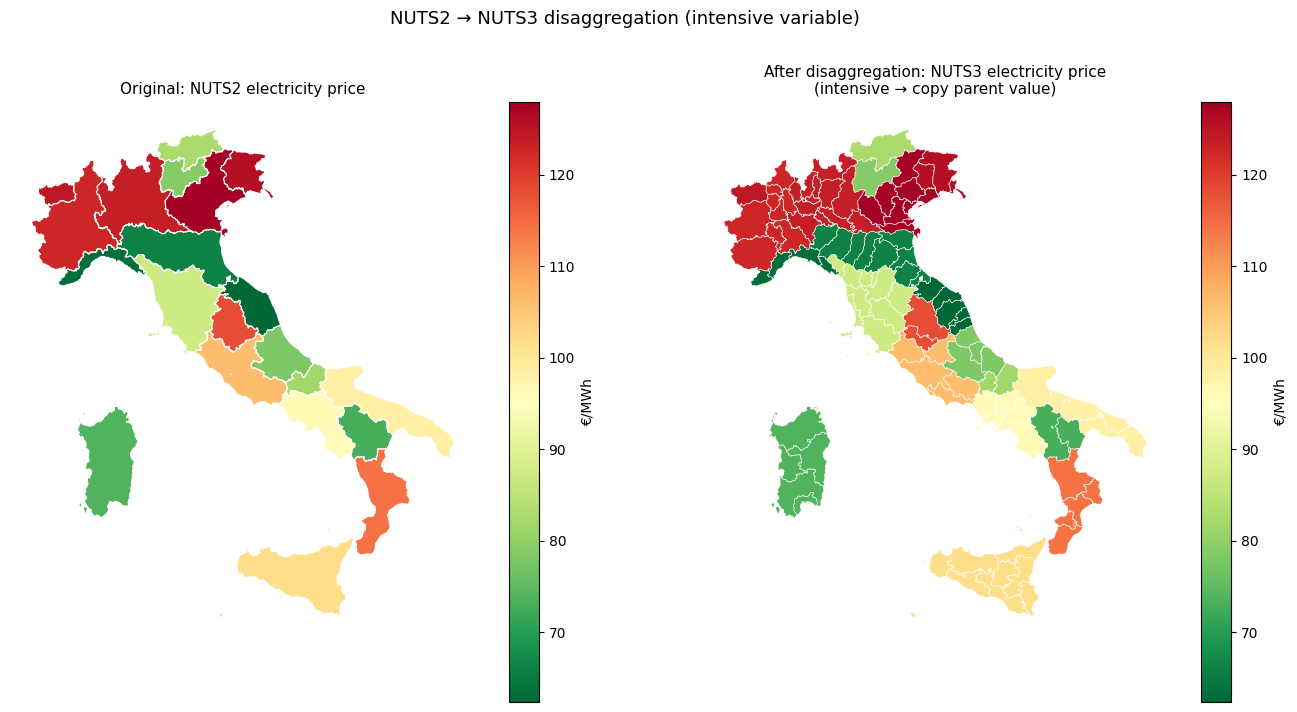

In [51]:
# --- Visualise the result: NUTS2 vs NUTS3 maps side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Merge NUTS2 geodata with the data table so we can plot it
nuts2_plot = nuts2_country.merge(nuts2_data, left_on='NUTS_ID', right_on='NUTS2_ID')

vmin = nuts2_data['price_eur_mwh'].min()
vmax = nuts2_data['price_eur_mwh'].max()

nuts2_plot.plot(
    ax=axes[0], column='price_eur_mwh',
    cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
    edgecolor='white', linewidth=0.8, legend=True,
    legend_kwds={'label': '€/MWh'}
)
axes[0].set_title('Original: NUTS2 electricity price', fontsize=11)
axes[0].set_axis_off()

nuts3_joined.plot(
    ax=axes[1], column='price_eur_mwh_nuts3',
    cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
    edgecolor='white', linewidth=0.4, legend=True,
    legend_kwds={'label': '€/MWh'}
)
axes[1].set_title('After disaggregation: NUTS3 electricity price\n(intensive → copy parent value)', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('NUTS2 → NUTS3 disaggregation (intensive variable)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Notice: the colour gradient at NUTS3 is the same as NUTS2 — each region copies its parent.
# This is correct for intensive variables. The finer borders just give more spatial detail.

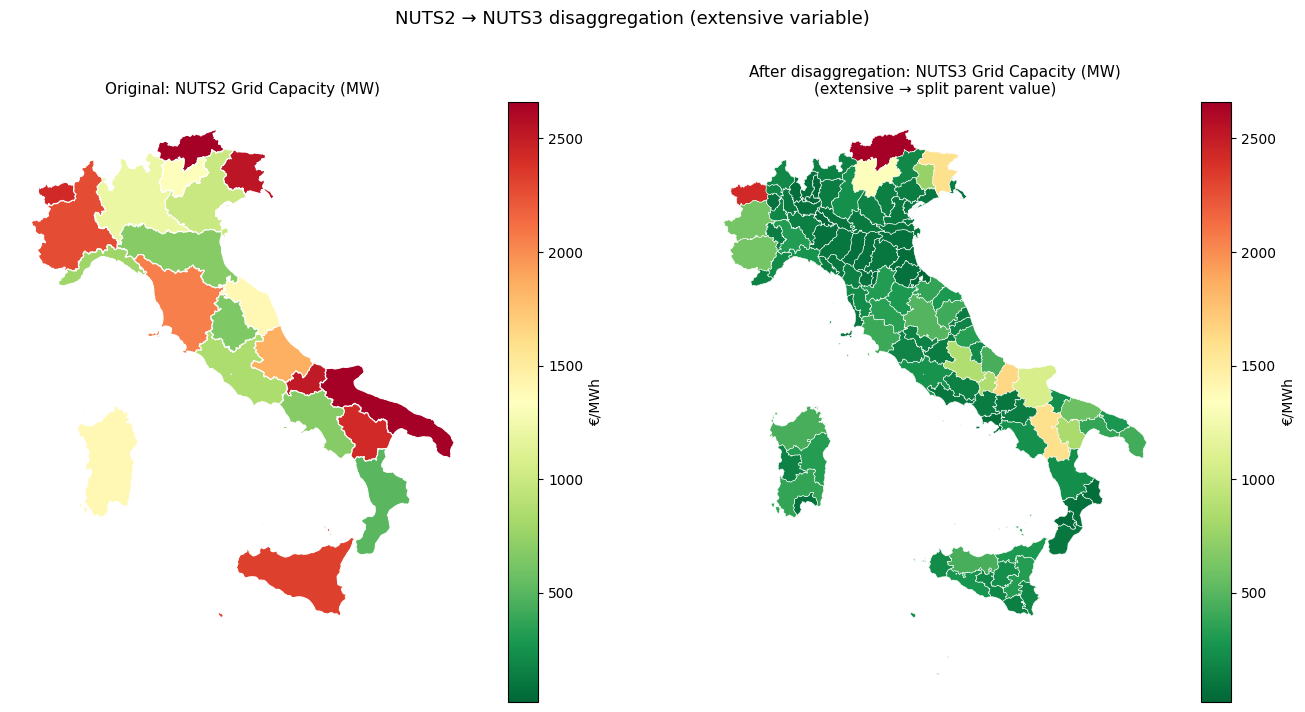

In [62]:
# --- Visualise the result: NUTS2 vs NUTS3 maps side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Merge NUTS2 geodata with the data table so we can plot it
nuts2_plot = nuts2_country.merge(nuts2_data, left_on='NUTS_ID', right_on='NUTS2_ID')

vmin = nuts3_joined['capacity_mw_nuts3'].min()
vmax = nuts3_joined['capacity_mw_nuts3'].max()


nuts2_plot.plot(
    ax=axes[0], column='capacity_mw_total',
    cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
    edgecolor='white', linewidth=0.8, legend=True,
    legend_kwds={'label': '€/MWh'}
)
axes[0].set_title('Original: NUTS2 Grid Capacity (MW)', fontsize=11)
axes[0].set_axis_off()

nuts3_joined.plot(
    ax=axes[1], column='capacity_mw_nuts3',
    cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
    edgecolor='white', linewidth=0.4, legend=True,
    legend_kwds={'label': '€/MWh'}
)
axes[1].set_title('After disaggregation: NUTS3 Grid Capacity (MW)\n(extensive → split parent value)', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('NUTS2 → NUTS3 disaggregation (extensive variable)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Notice: the colour gradient at NUTS3 is the same as NUTS2 — each region copies its parent.
# This is correct for intensive variables. The finer borders just give more spatial detail.

**When does the simple area-weighting fail?**

Area weighting assumes the variable is **uniformly distributed** inside the parent polygon.  
This is often unrealistic. For example:
- Grid capacity is concentrated near cities, not uniform across the NUTS2 region.
- Energy consumption follows population density, not land area.

A better approach is **dasymetric mapping**: use a third variable (e.g., population, built-up area)  
as a proxy to weight the disaggregation. We will see a simplified version of this in Part 6.

---
## Part 5 — Case B: Data on a 1 km × 1 km Grid → Aggregate to NUTS3

**Scenario:** Your data comes as a regular grid (e.g., from a satellite or climate model).  
Each cell is 1 km × 1 km and has one value. You want one value per NUTS3 polygon.

**Approach:** 
1. Assign each grid cell to the NUTS3 polygon it falls inside (spatial join).
2. Group by NUTS3 region and aggregate.

In Python, rasters are usually converted to vector points (or small polygons) for this operation,  
or handled directly with the `rasterstats` library (shown at the end of this part).

In [78]:
# --- Build a synthetic 1km × 1km grid over Italy ---
# In EPSG:3035 (metres), 1 km = 1000 units.

# Get the bounding box of Italy in metres
bbox_it = nuts3_country.total_bounds   # [minx, miny, maxx, maxy]
print("Bounding box (EPSG:3035):", bbox_it.round(0))

# Create a regular grid of points every 10 km (we use 10 km to keep the demo fast)
# In a real case, use 1000 for a 1 km grid
step = 10_000   # 10 km in metres

xs = np.arange(bbox_it[0], bbox_it[2], step)   # x coordinates (columns)
ys = np.arange(bbox_it[1], bbox_it[3], step)   # y coordinates (rows)

# Create all combinations of x and y
grid_x, grid_y = np.meshgrid(xs, ys)
grid_x = grid_x.flatten()
grid_y = grid_y.flatten()

print(f"Total grid points: {len(grid_x):,}")

# Assign a synthetic value to each cell
# For example, imagine this is solar irradiation (kWh/m²/year)
# We add a south-north gradient (higher in the south) + random noise
synthetic_value = (
    1400                                             # baseline
    - (grid_y - grid_y.min()) / (grid_y.max() - grid_y.min()) * 300   # gradient
    + np.random.normal(0, 30, len(grid_x))           # noise
).round(1)

# Build a GeoDataFrame with Point geometry for each cell centre
grid_gdf = gpd.GeoDataFrame({
    'value': synthetic_value
}, geometry=gpd.points_from_xy(grid_x, grid_y), crs='EPSG:3035')

grid_gdf.head()

Bounding box (EPSG:3035): [4055225. 1386124. 5049412. 2666691.]
Total grid points: 12,900


,value,geometry
0,1462.6,POINT (4055225.363 1386123.518)
1,1408.3,POINT (4065225.363 1386123.518)
2,1360.1,POINT (4075225.363 1386123.518)
3,1394.9,POINT (4085225.363 1386123.518)
4,1417.3,POINT (4095225.363 1386123.518)


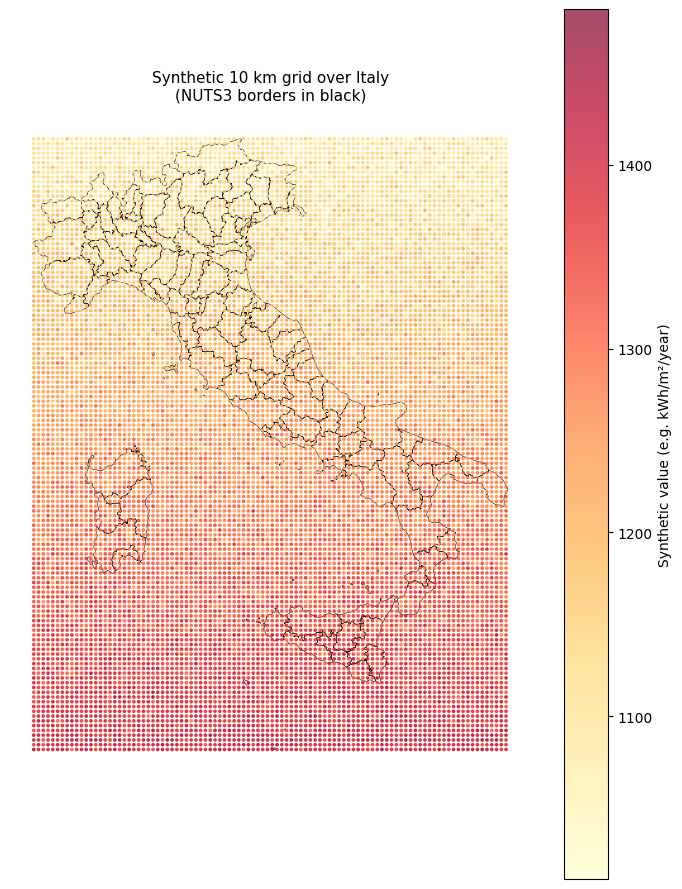

In [79]:
# --- Visualise the raw grid ---
fig, ax = plt.subplots(figsize=(7, 9))

# Plot NUTS3 borders as background
nuts3_country.plot(ax=ax, color='none', edgecolor='black', linewidth=0.4)

# Plot grid points coloured by value
sc = ax.scatter(
    grid_gdf.geometry.x, grid_gdf.geometry.y,
    c=grid_gdf['value'], cmap='YlOrRd',
    s=3, alpha=0.7
)
plt.colorbar(sc, ax=ax, label='Synthetic value (e.g. kWh/m²/year)')
ax.set_title('Synthetic 10 km grid over Italy\n(NUTS3 borders in black)', fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [80]:
# --- Spatial join: assign each grid point to a NUTS3 polygon ---
# gpd.sjoin(left, right, predicate) finds, for each row in 'left',
# which row in 'right' contains it (predicate='within').

# Both layers must be in the same CRS!
print("Grid CRS  :", grid_gdf.crs)
print("NUTS3 CRS :", nuts3_country.crs)

# Perform the join
# Each grid point gets the attributes of the NUTS3 polygon that contains it.
# Points outside all NUTS3 polygons (e.g., in the sea) are dropped by default.
grid_joined = gpd.sjoin(
    grid_gdf,                # left: grid points (we look these up)
    nuts3_country[['NUTS_ID', 'NAME_LATN', 'geometry']],  # right: NUTS3 polygons
    how='left',              # keep all grid points
    predicate='within'       # condition: grid point must be WITHIN the polygon
)

# Points that fell outside all polygons have NaN in NUTS_ID
n_outside = grid_joined['NUTS_ID'].isna().sum()
print(f"\nGrid points outside any NUTS3 polygon (e.g. sea): {n_outside}")

# Keep only the points that landed inside a polygon
grid_joined = grid_joined.dropna(subset=['NUTS_ID'])

grid_joined[['value', 'NUTS_ID', 'NAME_LATN']].head()

Grid CRS  : EPSG:3035
NUTS3 CRS : EPSG:3035

Grid points outside any NUTS3 polygon (e.g. sea): 9898


,value,NUTS_ID,NAME_LATN
1445,1421.1,ITG11,Trapani
1568,1348.3,ITG18,Ragusa
1569,1331.2,ITG18,Ragusa
1570,1398.3,ITG18,Ragusa
1571,1326.8,ITG18,Ragusa


In [81]:
# --- Aggregate grid values to NUTS3 ---
# The right aggregation depends on whether the variable is intensive or extensive.

nuts3_aggregated = grid_joined.groupby('NUTS_ID').agg(
    # Intensive variable: use mean (or area-weighted mean — see below)
    value_mean  = ('value', 'mean'),
    value_min   = ('value', 'min'),
    value_max   = ('value', 'max'),
    # Extensive variable: use sum
    # value_sum = ('value', 'sum'),   # uncomment for extensive variables
    # Count how many grid cells contributed
    cell_count  = ('value', 'count'),
).reset_index()

print(f"NUTS3 regions with at least one grid cell: {len(nuts3_aggregated)}")
nuts3_aggregated.head()

NUTS3 regions with at least one grid cell: 107


,NUTS_ID,value_mean,value_min,value_max,cell_count
0,ITC11,1159.680597,1067.9,1254.1,67
1,ITC12,1145.540909,1099.3,1189.7,22
2,ITC13,1132.322222,1092.6,1164.2,9
3,ITC14,1109.009524,1057.3,1177.9,21
4,ITC15,1145.692857,1099.2,1188.6,14


NUTS3 regions with no data: 0


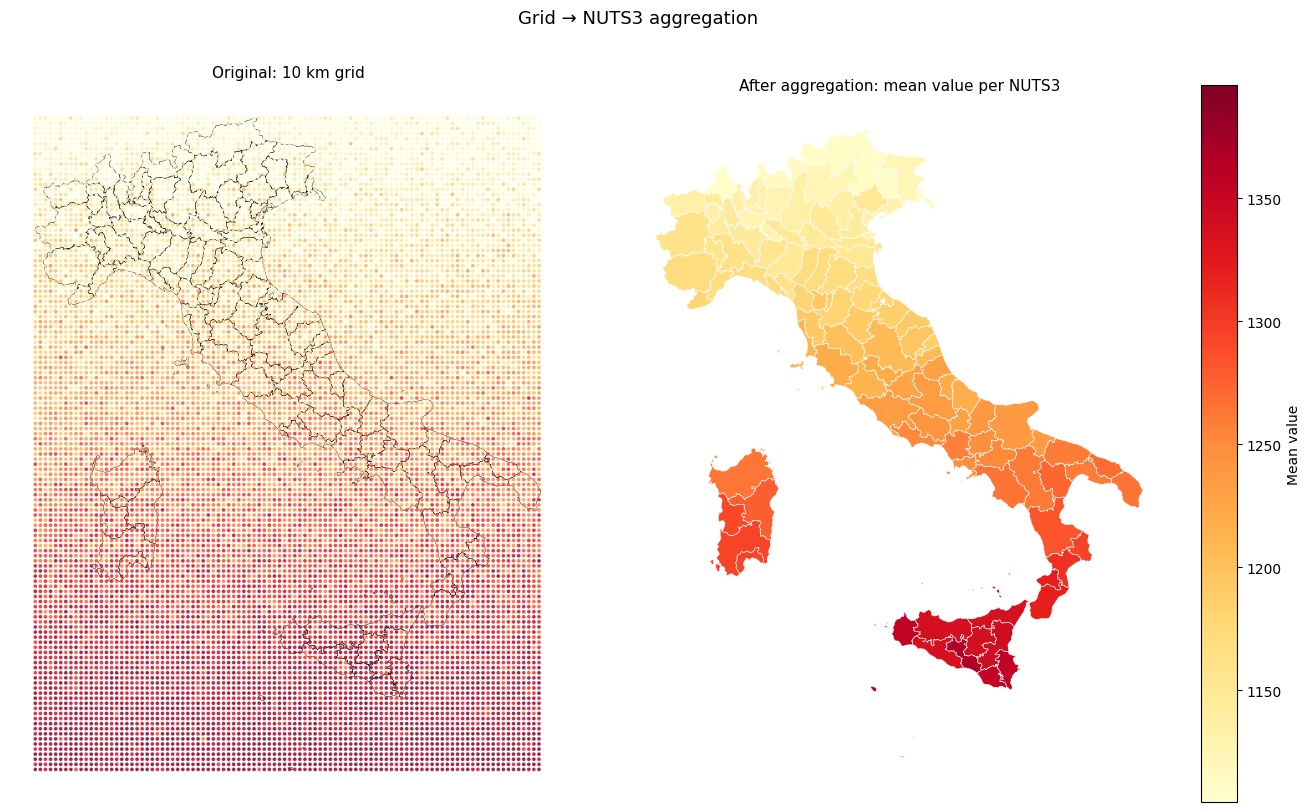

In [82]:
# --- Merge the aggregated values back to the NUTS3 GeoDataFrame ---
nuts3_result = nuts3_country.merge(nuts3_aggregated, on='NUTS_ID', how='left')

# NUTS3 regions with no grid cell inside will have NaN — flag them
print(f"NUTS3 regions with no data: {nuts3_result['value_mean'].isna().sum()}")

# --- Plot the aggregated map ---
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: raw grid points
nuts3_country.plot(ax=axes[0], color='none', edgecolor='black', linewidth=0.3)
sc = axes[0].scatter(
    grid_gdf.geometry.x, grid_gdf.geometry.y,
    c=grid_gdf['value'], cmap='YlOrRd',
    s=3, alpha=0.7,
    vmin=grid_gdf['value'].quantile(0.05),
    vmax=grid_gdf['value'].quantile(0.95)
)
axes[0].set_title('Original: 10 km grid', fontsize=11)
axes[0].set_axis_off()

# Right: aggregated NUTS3 choropleth
nuts3_result.plot(
    ax=axes[1], column='value_mean',
    cmap='YlOrRd', legend=True,
    edgecolor='white', linewidth=0.4,
    legend_kwds={'label': 'Mean value'},
    vmin=grid_gdf['value'].quantile(0.05),
    vmax=grid_gdf['value'].quantile(0.95)
)
axes[1].set_title('After aggregation: mean value per NUTS3', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('Grid → NUTS3 aggregation', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Important note on small NUTS3 regions:**

Small regions (e.g., city-states like Berlin or Luxembourg city) may contain very few grid cells.  
Always check `cell_count` before trusting the aggregate. Regions with fewer than ~5 cells  
have high uncertainty in their estimated mean.

**Working with real rasters:**

If your data is a `.tif` raster file, the `rasterstats` library lets you avoid
converting to points altogether:
```python
from rasterstats import zonal_stats
stats = zonal_stats('nuts3.shp', 'my_raster.tif', stats=['mean', 'sum', 'count'])
```
This is much faster and handles edge cells automatically.

---
## Part 6 — Case C: Partial Overlap — Areal Interpolation

This is the most general and important case.

**Scenario:** Your source polygons do not align with the NUTS3 boundaries.  
A source polygon may overlap with **multiple** NUTS3 regions — partly inside one, partly inside another.

**Example:** a municipality boundary, a watershed, an administrative zone from a different country,  
or any dataset that uses its own spatial unit.

**Solution: Areal Interpolation**
1. Compute the intersection of source polygons with target (NUTS3) polygons.
2. For each intersection piece, compute its share of the source polygon's area.
3. Multiply the source value by that area share.
4. Sum all pieces that fall into the same NUTS3 region.

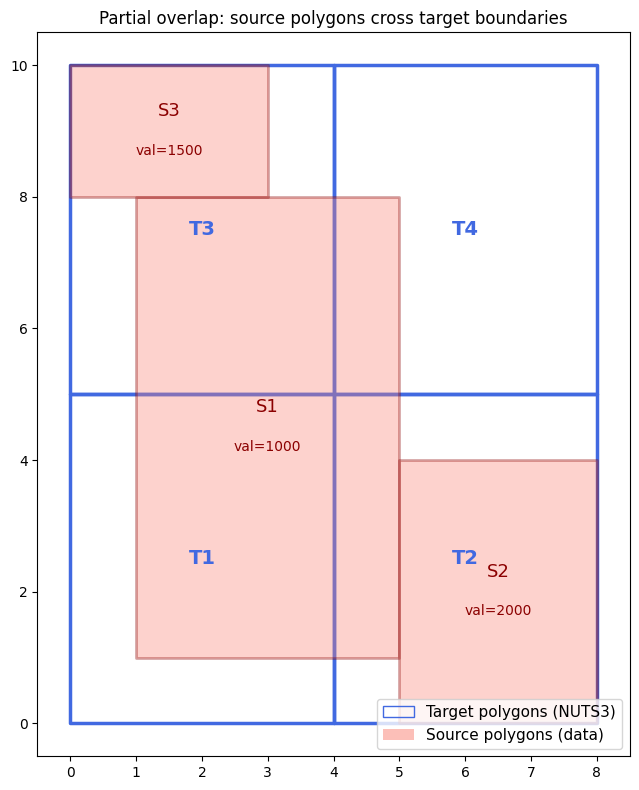

Source S1 overlaps FOUR target polygons — we must split its value proportionally.


In [85]:
# --- Build a simple synthetic example to understand the concept ---
# We create 3 'source' polygons that overlap with 4 'target' polygons.

# Target polygons (think: NUTS3 regions)
targets = gpd.GeoDataFrame({
    'target_id': ['T1', 'T2', 'T3', 'T4'],
    'geometry': [
        box(0, 0, 4, 5),
        box(4, 0, 8, 5),
        box(0, 5, 4, 10),
        box(4, 5, 8, 10),
    ]
}, crs='EPSG:3035')

# Source polygons (think: data at a different spatial resolution)
# Notice: they do NOT align with the target polygons
sources = gpd.GeoDataFrame({
    'source_id'     : ['S1',  'S2',  'S3'],
    'value_intensive': [100,   200,   150],  # e.g. price €/unit (intensive)
    'value_extensive': [1000,  2000,  1500], # e.g. total MWh (extensive)
    'geometry': [
        box(1, 1, 5, 8),    # overlaps T1, T2, T3, T4
        box(5, 0, 8, 4),    # overlaps T2 only
        box(0, 8, 3, 10),   # overlaps T3 only
    ]
}, crs='EPSG:3035')

# --- Visualise the overlap ---
fig, ax = plt.subplots(figsize=(8, 8))

# Target polygons: blue borders
targets.plot(ax=ax, color='none', edgecolor='royalblue', linewidth=2.5, label='Target (NUTS3)')

# Source polygons: red, semi-transparent fill
sources.plot(ax=ax, color='salmon', alpha=0.35, edgecolor='darkred', linewidth=2)

# Add labels
for _, r in targets.iterrows():
    cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
    ax.text(cx, cy, r['target_id'], color='royalblue', fontsize=14, ha='center', va='center', fontweight='bold')

for _, r in sources.iterrows():
    cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
    ax.text(cx, cy + 0.3, r['source_id'], color='darkred', fontsize=13, ha='center', va='center')
    ax.text(cx, cy - 0.3, f"val={r['value_extensive']}", color='darkred', fontsize=10, ha='center', va='center')

# Legend
blue_patch  = mpatches.Patch(edgecolor='royalblue', facecolor='none', label='Target polygons (NUTS3)')
red_patch   = mpatches.Patch(facecolor='salmon', alpha=0.5, label='Source polygons (data)')
ax.legend(handles=[blue_patch, red_patch], loc='lower right', fontsize=11)

ax.set_title('Partial overlap: source polygons cross target boundaries', fontsize=12)
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

print("Source S1 overlaps FOUR target polygons — we must split its value proportionally.")

In [ ]:
# --- Step 1: Compute the intersection of source and target polygons ---
# gpd.overlay(A, B, how='intersection') returns all the pieces where A and B overlap.
# Each row in the result is one intersection fragment.

intersection = gpd.overlay(
    sources,   # left layer (the data)
    targets,   # right layer (the target geography)
    how='intersection'
)

print(f"Number of intersection pieces: {len(intersection)}")
print("\nEach row = one piece of a source polygon inside one target polygon:")
intersection

Number of intersection pieces: 6

Each row = one piece of a source polygon inside one target polygon:


,source_id,value_intensive,value_extensive,target_id,geometry
0,S1,100,1000,T1,"POLYGON ((1 1, 1 5, 4 5, 4 1, 1 1))"
1,S1,100,1000,T2,"POLYGON ((5 1, 4 1, 4 5, 5 5, 5 1))"
2,S1,100,1000,T3,"POLYGON ((1 8, 4 8, 4 5, 1 5, 1 8))"
3,S1,100,1000,T4,"POLYGON ((5 8, 5 5, 4 5, 4 8, 5 8))"
4,S2,200,2000,T2,"POLYGON ((8 0, 5 0, 5 4, 8 4, 8 0))"
5,S3,150,1500,T3,"POLYGON ((3 8, 0 8, 0 10, 3 10, 3 8))"


In [89]:
# --- Step 2: Compute the area of each intersection piece ---
intersection['intersect_area'] = intersection.geometry.area

# --- Step 3: Compute the total area of each original source polygon ---
# We need to know: "what fraction of S1 falls inside T1?"
intersection['source_area'] = intersection['source_id'].map(
    sources.set_index('source_id').geometry.area
)

# --- Step 4: Area weight = fraction of the source polygon in this intersection piece ---
intersection['area_weight'] = intersection['intersect_area'] / intersection['source_area']

# Check: for each source, weights should sum to (approximately) 1.0
# (they sum to exactly 1 if the source polygon is fully covered by targets)
print("Area weights per source polygon (should sum to ~1.0):")
print(intersection.groupby('source_id')['area_weight'].sum().round(4))

intersection[['source_id', 'target_id', 'intersect_area', 'source_area', 'area_weight']].round(3)

Area weights per source polygon (should sum to ~1.0):
source_id
S1    1.0
S2    1.0
S3    1.0
Name: area_weight, dtype: float64


,source_id,target_id,intersect_area,source_area,area_weight
0,S1,T1,12.0,28.0,0.429
1,S1,T2,4.0,28.0,0.143
2,S1,T3,9.0,28.0,0.321
3,S1,T4,3.0,28.0,0.107
4,S2,T2,12.0,12.0,1.000
5,S3,T3,6.0,6.0,1.000


In [90]:
# --- Step 5: Apply the area weight to each variable ---

# For an EXTENSIVE variable: multiply by the weight, then SUM over target
# Logic: if 30% of S1 (which has value 1000) falls in T1 → T1 gets 300 from S1
intersection['contrib_extensive'] = intersection['value_extensive'] * intersection['area_weight']

# For an INTENSIVE variable: weight the values before averaging
# Logic: each piece contributes to an area-weighted average within the target polygon
intersection['contrib_intensive_num'] = intersection['value_intensive'] * intersection['intersect_area']

# --- Step 6: Aggregate to the target level ---
result = intersection.groupby('target_id').agg(
    # Extensive: sum the weighted contributions
    value_extensive_interp = ('contrib_extensive', 'sum'),
    # Intensive: area-weighted average = sum(value * area) / sum(area)
    value_intensive_num    = ('contrib_intensive_num', 'sum'),
    value_intensive_denom  = ('intersect_area', 'sum'),
).reset_index()

result['value_intensive_interp'] = (
    result['value_intensive_num'] / result['value_intensive_denom']
).round(1)

result = result[['target_id', 'value_extensive_interp', 'value_intensive_interp']]
result['value_extensive_interp'] = result['value_extensive_interp'].round(1)

print("Interpolated values at the target (NUTS3) level:")
result

Interpolated values at the target (NUTS3) level:


,target_id,value_extensive_interp,value_intensive_interp
0,T1,428.6,100.0
1,T2,2142.9,175.0
2,T3,1821.4,120.0
3,T4,107.1,100.0


In [91]:
# --- Quick sanity check for the extensive variable ---
# The sum of all target values should equal the sum of all source values
# (no value is created or destroyed — it is just redistributed)

source_total = sources['value_extensive'].sum()
target_total = result['value_extensive_interp'].sum()

print(f"Sum of source values : {source_total}")
print(f"Sum of target values : {target_total:.1f}")
print(f"Difference           : {abs(source_total - target_total):.2f}  (should be ~0)")

Sum of source values : 4500
Sum of target values : 4500.0
Difference           : 0.00  (should be ~0)


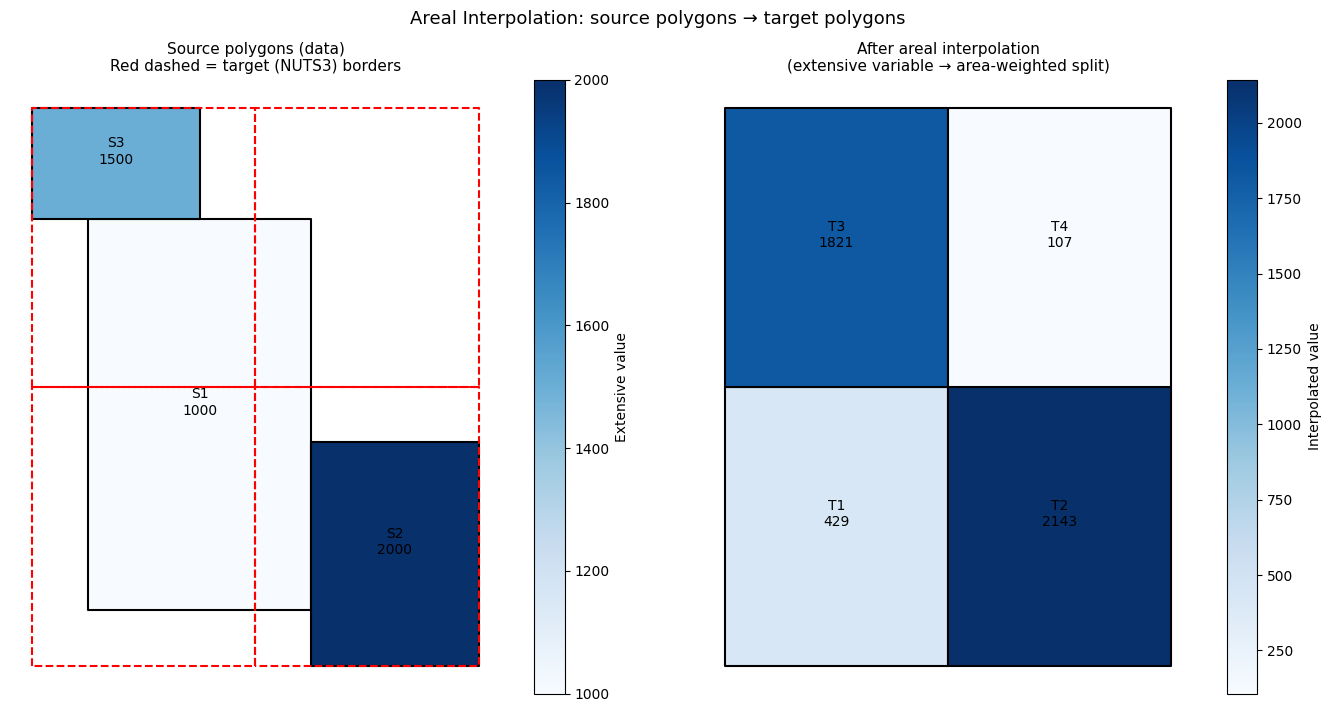

In [92]:
# --- Visualise the areal interpolation result ---

targets_result = targets.merge(result, on='target_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: source polygons coloured by their value
sources.plot(
    ax=axes[0], column='value_extensive',
    cmap='Blues', legend=True, edgecolor='black', linewidth=1.5,
    legend_kwds={'label': 'Extensive value'}
)
targets.plot(ax=axes[0], color='none', edgecolor='red', linewidth=1.5, linestyle='--')
for _, r in sources.iterrows():
    cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
    axes[0].text(cx, cy, f"{r['source_id']}\n{int(r['value_extensive'])}", ha='center', fontsize=10)
axes[0].set_title('Source polygons (data)\nRed dashed = target (NUTS3) borders', fontsize=11)
axes[0].set_axis_off()

# Right: target polygons coloured by the interpolated value
targets_result.plot(
    ax=axes[1], column='value_extensive_interp',
    cmap='Blues', legend=True, edgecolor='black', linewidth=1.5,
    legend_kwds={'label': 'Interpolated value'}
)
for _, r in targets_result.iterrows():
    cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
    val = r['value_extensive_interp']
    label = f"{r['target_id']}\n{val:.0f}" if not pd.isna(val) else r['target_id']
    axes[1].text(cx, cy, label, ha='center', fontsize=10)
axes[1].set_title('After areal interpolation\n(extensive variable → area-weighted split)', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('Areal Interpolation: source polygons → target polygons', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

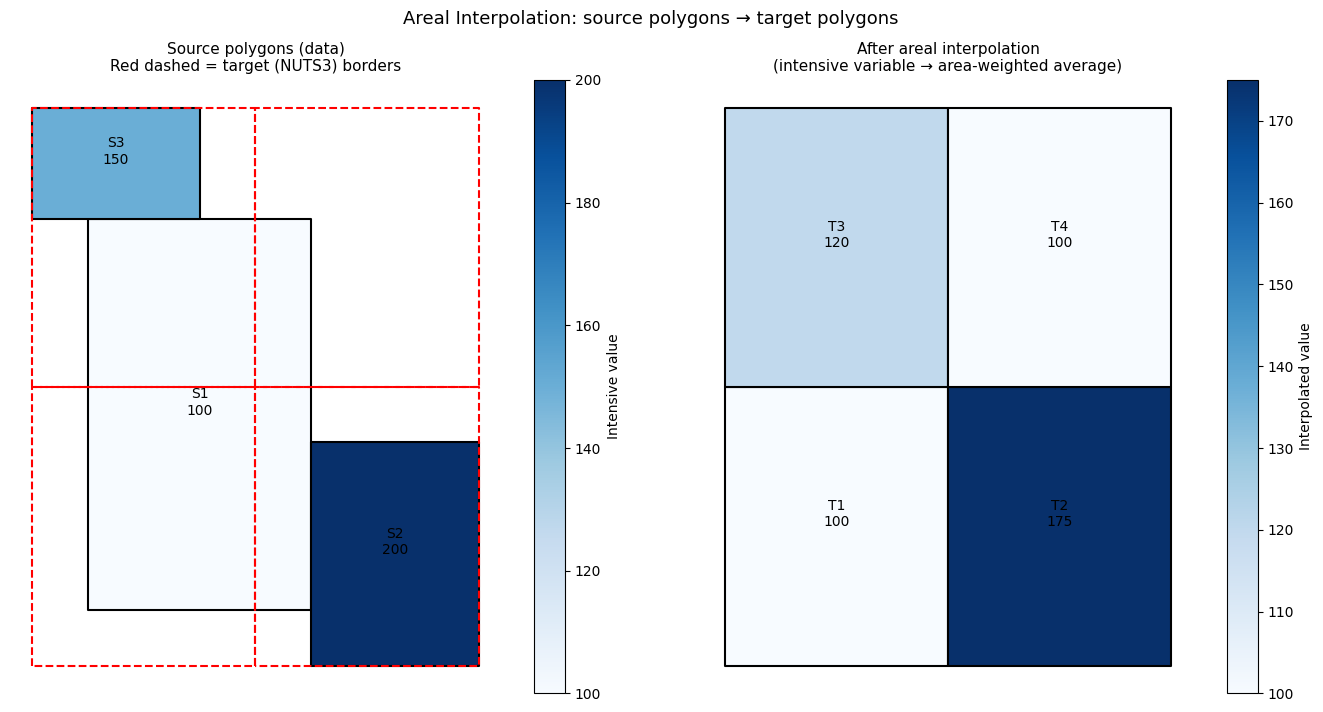

In [94]:
# --- Visualise the areal interpolation result ---

targets_result = targets.merge(result, on='target_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: source polygons coloured by their value
sources.plot(
    ax=axes[0], column='value_intensive',
    cmap='Blues', legend=True, edgecolor='black', linewidth=1.5,
    legend_kwds={'label': 'Intensive value'}
)
targets.plot(ax=axes[0], color='none', edgecolor='red', linewidth=1.5, linestyle='--')
for _, r in sources.iterrows():
    cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
    axes[0].text(cx, cy, f"{r['source_id']}\n{int(r['value_intensive'])}", ha='center', fontsize=10)
axes[0].set_title('Source polygons (data)\nRed dashed = target (NUTS3) borders', fontsize=11)
axes[0].set_axis_off()

# Right: target polygons coloured by the interpolated value
targets_result.plot(
    ax=axes[1], column='value_intensive_interp',
    cmap='Blues', legend=True, edgecolor='black', linewidth=1.5,
    legend_kwds={'label': 'Interpolated value'}
)
for _, r in targets_result.iterrows():
    cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
    val = r['value_intensive_interp']
    label = f"{r['target_id']}\n{val:.0f}" if not pd.isna(val) else r['target_id']
    axes[1].text(cx, cy, label, ha='center', fontsize=10)
axes[1].set_title('After areal interpolation\n(intensive variable → area-weighted average)', fontsize=11)
axes[1].set_axis_off()

plt.suptitle('Areal Interpolation: source polygons → target polygons', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.1 — Limitations of Areal Interpolation

Areal interpolation makes one big assumption:

> **The variable is uniformly distributed inside each source polygon.**

This is almost always wrong. For example:
- Population is concentrated in cities, not spread evenly across the region.
- Solar capacity is on south-facing roofs, not on every square metre.
- Drought stress is higher on agricultural land, not on forests.

**What to do instead?**

Use **dasymetric mapping**: instead of weighting by area, weight by a **proxy variable**  
that better represents the distribution of your target variable.

| Target variable | Good proxy |
|----------------|------------|
| Population-driven variables | Population density grid (e.g. GHS-POP) |
| Energy demand | Built-up area (e.g. GHS-BUILT) |
| Agricultural water use | Cropland area (e.g. CORINE Land Cover classes 2xx) |
| Economic activity | Night-time light intensity (VIIRS) |

The logic is the same as areal interpolation, but you replace `area_weight` with `proxy_weight`.

The `tobler` Python library implements areal interpolation and dasymetric mapping efficiently:  
https://pysal.org/tobler/

### 6.2 — Edge Cells: "Half in, Half Out"

When a source polygon (or grid cell) sits exactly on the border of a NUTS3 polygon,  
you have to decide how to count it. There are three standard strategies:

| Strategy | When to use |
|---------|-------------|
| **Centroid-in** | Assign the cell to the region that contains its centre point. Fast, but ignores the actual area of overlap. |
| **Area majority** | Assign the cell to the region that contains the **most** of its area. A better approximation. |
| **Fractional / areal interpolation** | Split the value proportionally to the area of overlap (what we did in Part 6). The most correct approach. |

**In practice:**
- For large polygons (NUTS3 is typically hundreds of km²) and small grid cells (1 km), the centroid rule is usually good enough — few cells straddle the border significantly.
- For small regions (e.g., city NUTS3) or large source polygons, use fractional interpolation.
- Always check: what fraction of your total area is made up of edge cells?

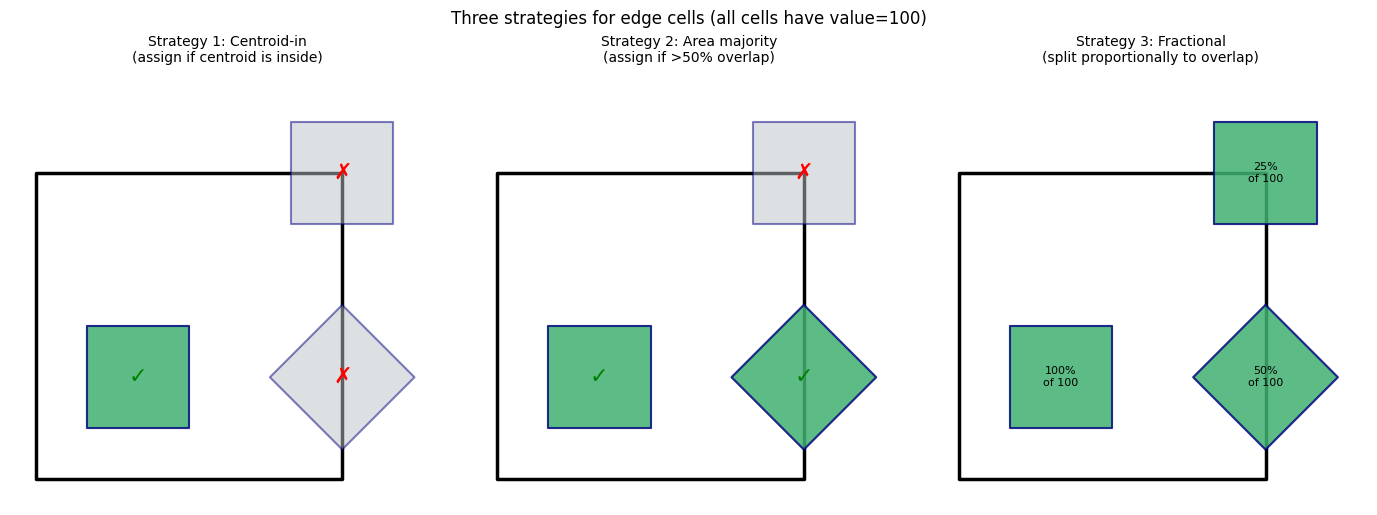

In [104]:
from shapely.affinity import rotate
# --- Illustrate the three edge cell strategies with a tiny example ---

# One target polygon (the NUTS3 region we care about)
target = gpd.GeoDataFrame({'id': ['NUTS3'], 'geometry': [box(0, 0, 6, 6)]}, crs='EPSG:3035')

# Three 2x2 grid cells: one fully inside, one half-in half-out, one mostly outside
cells = gpd.GeoDataFrame({
    'cell_id' : ['Fully inside',      'Half in / half out',  'Mostly outside'],
    'value'   : [100,                  100,                   100],
    'geometry': [
        box(1, 1, 3, 3),    # 100% inside
        rotate(box(5, 1, 7, 3,), 45, origin='center'),# 50% inside (right half is outside)
        box(5, 5, 7, 7),    # 25% inside (top-right corner only)
    ]
}, crs='EPSG:3035')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
titles = ['Strategy 1: Centroid-in\n(assign if centroid is inside)',
          'Strategy 2: Area majority\n(assign if >50% overlap)',
          'Strategy 3: Fractional\n(split proportionally to overlap)']

# Compute which cells qualify under each strategy
# Strategy 1: centroid inside target
centroids = cells.geometry.centroid
strategy1_inside = cells[centroids.within(target.geometry.iloc[0])]

# Strategy 2: area majority (>50% overlap)
inter = gpd.overlay(cells, target, how='intersection')
inter['frac'] = inter.geometry.area / inter['cell_id'].map(cells.set_index('cell_id').geometry.area)
strategy2_inside = cells[cells['cell_id'].isin(inter[inter['frac'] > 0.5]['cell_id'])]

# Strategy 3: fractional (shown numerically, all cells contribute)
inter['contrib'] = inter['value'] * inter['frac']
total_fractional = inter['contrib'].sum()

colors_all = ['#2ecc71', '#e74c3c', '#e74c3c']  # green = included, red = excluded

for ax, strat, title in zip(axes, [strategy1_inside, strategy2_inside, cells], titles):
    target.plot(ax=ax, color='none', edgecolor='black', linewidth=2.5)
    cells.plot(ax=ax, color='#bdc3c7', edgecolor='navy', linewidth=1.5, alpha=0.5)
    strat.plot(ax=ax, color='#27ae60', edgecolor='navy', linewidth=1.5, alpha=0.7)
    
    # Labels
    for _, r in cells.iterrows():
        cx, cy = r.geometry.centroid.x, r.geometry.centroid.y
        if ax == axes[2]:  # fractional: show the fraction
            frac_row = inter[inter['cell_id'] == r['cell_id']]
            f = frac_row['frac'].values[0] if len(frac_row) > 0 else 0
            ax.text(cx, cy, f"{f:.0%}\nof {r['value']}", ha='center', va='center', fontsize=8)
        else:
            included = r['cell_id'] in strat['cell_id'].values
            ax.text(cx, cy, '✓' if included else '✗', ha='center', va='center',
                    fontsize=16, color='green' if included else 'red')
    
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.5, 8)
    ax.set_ylim(-0.5, 8)
    ax.set_axis_off()

# Add strategy totals
s1_total = strategy1_inside['value'].sum()
s2_total = strategy2_inside['value'].sum()
axes[0].set_xlabel(f'Total attributed to NUTS3: {s1_total}', fontsize=10)
axes[1].set_xlabel(f'Total attributed to NUTS3: {s2_total}', fontsize=10)
axes[2].set_xlabel(f'Total attributed to NUTS3: {total_fractional:.1f}', fontsize=10)

plt.suptitle('Three strategies for edge cells (all cells have value=100)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Part 7 — Summary and Decision Guide

Here is a practical checklist to follow every time you need to bring data to NUTS3 level.

---

### Step 0 — Always do first
1. Check the CRS of both layers. **Reproject everything to the same CRS** before any operation.
2. Check the geometry for validity: `gdf.geometry.is_valid.all()`. Fix with `.buffer(0)` if needed.
3. Check for missing values and duplicate region codes.

---

### Decision tree

```
What is the spatial format of my data?
│
├── Polygons at a coarser level (e.g. NUTS2)
│       └── Are the boundaries nested? (NUTS2 exactly contains NUTS3?)
│               ├── Yes → Use code truncation + table join (Part 4)
│               │         Intensive var → copy value
│               │         Extensive var → split by area fraction
│               └── No  → Use overlay() + areal interpolation (Part 6)
│
├── Regular grid (raster / 1km cells)
│       └── Use spatial join (sjoin) + groupby aggregation (Part 5)
│             OR use rasterstats.zonal_stats() directly on the .tif file
│             Intensive var → mean (area-weighted if cells vary in size)
│             Extensive var → sum
│
└── Arbitrary polygons (don't align with NUTS)
        └── Use overlay() + areal interpolation (Part 6)
              For better results → dasymetric mapping with a proxy variable
```

---

### Common mistakes to avoid

| Mistake | Fix |
|---------|-----|
| CRS mismatch | Always check `.crs` and use `.to_crs()` before any spatial op |
| Summing an intensive variable | Use mean (or area-weighted mean), not sum |
| Ignoring edge cells | Decide on a strategy (centroid / majority / fractional) and document it |
| Assuming uniform distribution | Always think: *is this variable really spread evenly?* |
| Not checking conservation | For extensive vars, sum before == sum after (within tolerance) |
| NUTS version mismatch | Eurostat has NUTS 2013, 2016, 2021 — make sure data and shapefile use the same version |

---

### Useful libraries and resources

| Resource | Link |
|----------|------|
| GeoPandas documentation | https://geopandas.org/en/stable/ |
| Eurostat NUTS download | https://gisco-services.ec.europa.eu/distribution/v2/nuts/download/ |
| `tobler` — areal interpolation | https://pysal.org/tobler/ |
| `rasterstats` — raster → polygons | https://pythonhosted.org/rasterstats/ |
| GHS Population Grid (proxy for dasymetric) | https://ghsl.jrc.ec.europa.eu/ghs_pop2023.php |
| CORINE Land Cover | https://land.copernicus.eu/pan-european/corine-land-cover |